
Тест 1, сетка 64x64, h=0.0156
DEBUG: N=64, n_u=4160, n_v=4160, n_p=4096
Построение матриц...
  Au: (4160, 4160), nnz=19784
  Av: (4160, 4160), nnz=19784
  B1: (4160, 4096), nnz=7812
  B2: (4160, 4096), nnz=7812
Построение правой части...
Решение методом Удзавы...
iter=    0  ||r||=2.51e-02  tau=5.00e-01
Сходимость за 86 итераций, ||r||=9.74e-08
Время: 1.75 сек

Ошибки в L2-норме:
  ||u - u_h|| = 5.764161e-04
  ||v - v_h|| = 5.851480e-04
  ||p - p_h|| = 2.528319e-02


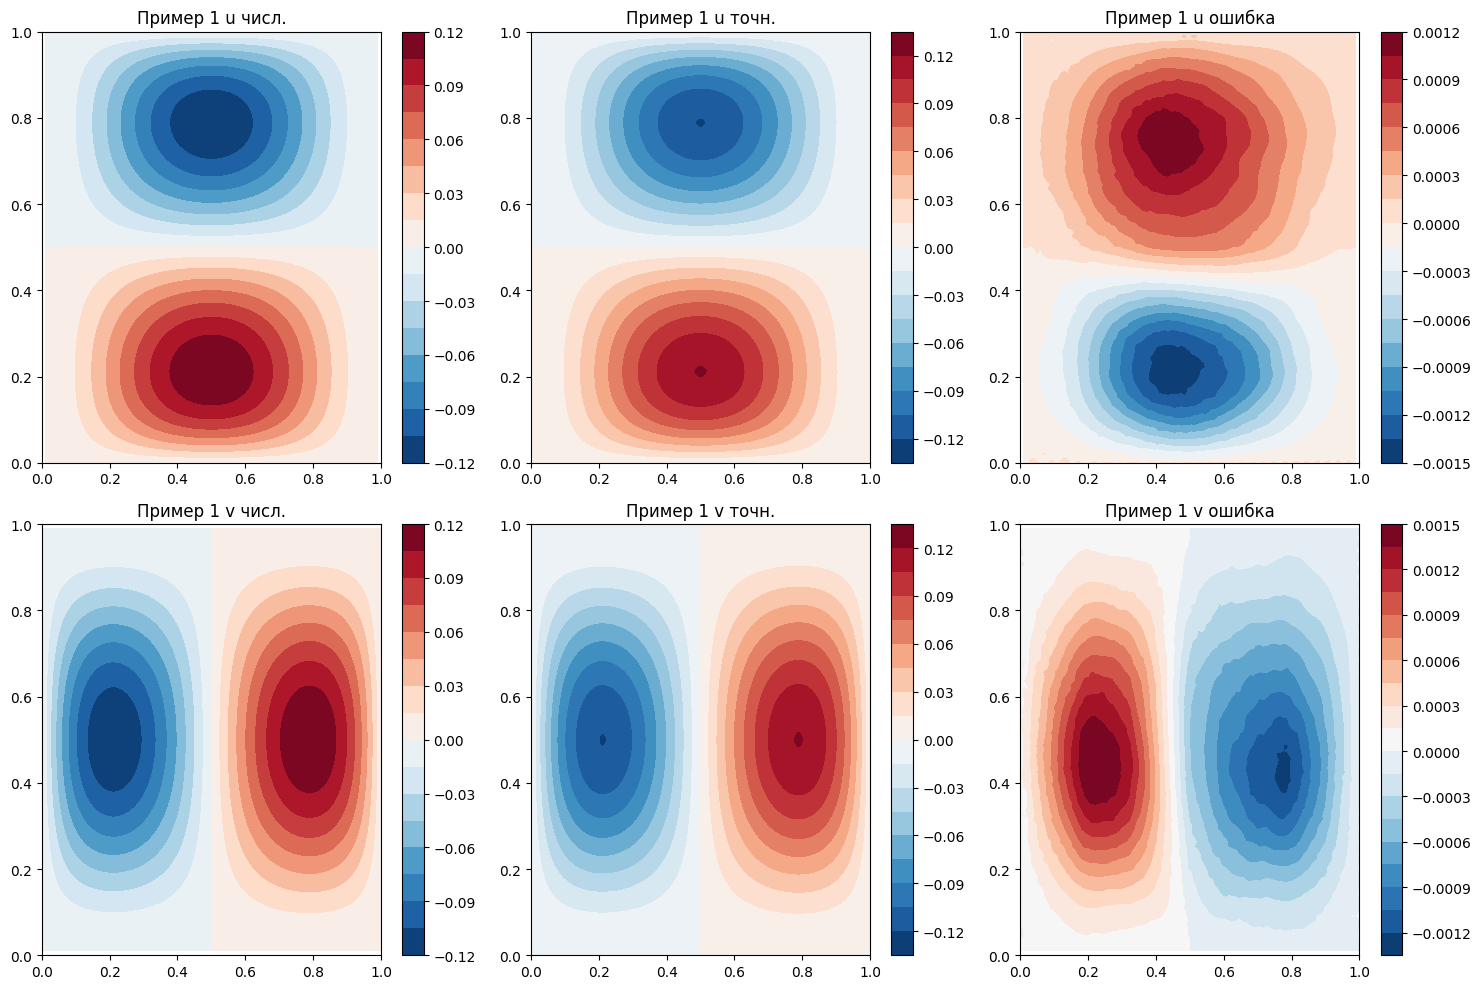

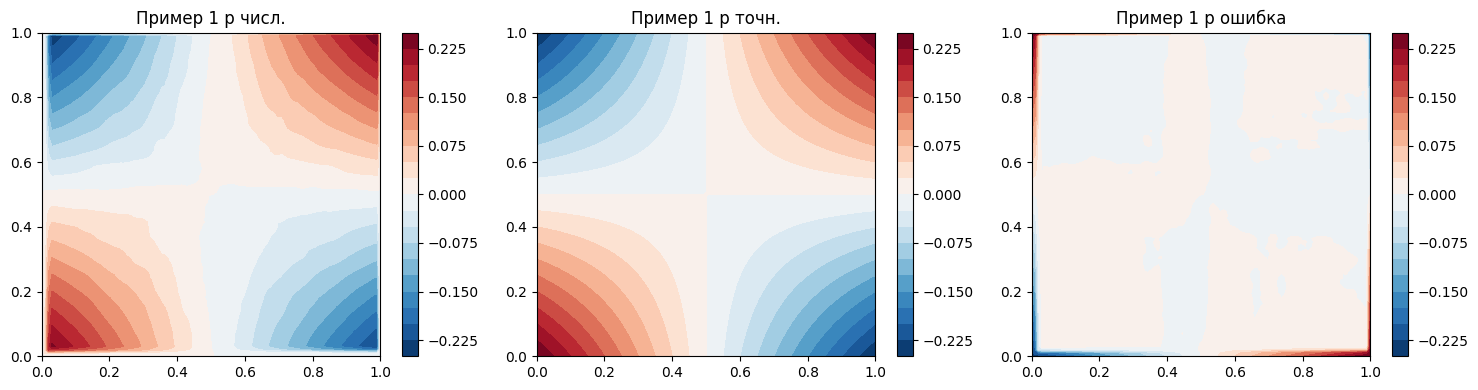

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import cg
import time
from scipy.interpolate import griddata

# ====================================================
# MAC-сетка
# ====================================================
class MACGrid:
    """Класс для работы с MAC-сеткой"""
    def __init__(self, N):
        self.N = N
        self.h = 1.0 / N
       
        self.nu_x = N
        self.nu_y = N + 1
        self.nv_x = N + 1
        self.nv_y = N
        self.np_x = N
        self.np_y = N
       
        self.n_u = self.nu_x * self.nu_y
        self.n_v = self.nv_x * self.nv_y
        self.n_p = self.np_x * self.np_y
       
        print(f"DEBUG: N={N}, n_u={self.n_u}, n_v={self.n_v}, n_p={self.n_p}")
       
        # Координаты
        self.x_u = (np.arange(self.nu_x) + 0.5) * self.h
        self.y_u = np.arange(self.nu_y) * self.h
        self.x_v = np.arange(self.nv_x) * self.h
        self.y_v = (np.arange(self.nv_y) + 0.5) * self.h
        self.x_p = (np.arange(self.np_x) + 0.5) * self.h
        self.y_p = (np.arange(self.np_y) + 0.5) * self.h
       
        self.X_full, self.Y_full = np.meshgrid(
            np.linspace(0, 1, 100), np.linspace(0, 1, 100), indexing='ij'
        )

    def idx_u(self, i, j):
        return i * self.nu_y + j

    def idx_v(self, i, j):
        return i * self.nv_y + j

    def idx_p(self, i, j):
        return i * self.np_y + j

# ====================================================
# Построение матриц (ИСПРАВЛЕНО!)
# ====================================================
def build_matrices(grid):
    h = grid.h
    h2_inv = 1.0 / (h * h)
    h_inv = 1.0 / h

    # ----------------- Au -----------------
    Au = lil_matrix((grid.n_u, grid.n_u))
    for i in range(grid.nu_x):
        for j in range(grid.nu_y):
            idx = grid.idx_u(i, j)
            if i == 0 or i == grid.nu_x - 1 or j == 0 or j == grid.nu_y - 1:
                Au[idx, idx] = 1.0
            else:
                Au[idx, idx] = 4.0 * h2_inv
                Au[idx, grid.idx_u(i-1, j)] = -h2_inv
                Au[idx, grid.idx_u(i+1, j)] = -h2_inv
                Au[idx, grid.idx_u(i, j-1)] = -h2_inv
                Au[idx, grid.idx_u(i, j+1)] = -h2_inv

    # ----------------- Av -----------------
    Av = lil_matrix((grid.n_v, grid.n_v))
    for i in range(grid.nv_x):
        for j in range(grid.nv_y):
            idx = grid.idx_v(i, j)
            if i == 0 or i == grid.nv_x - 1 or j == 0 or j == grid.nv_y - 1:
                Av[idx, idx] = 1.0
            else:
                Av[idx, idx] = 4.0 * h2_inv
                Av[idx, grid.idx_v(i-1, j)] = -h2_inv
                Av[idx, grid.idx_v(i+1, j)] = -h2_inv
                Av[idx, grid.idx_v(i, j-1)] = -h2_inv
                Av[idx, grid.idx_v(i, j+1)] = -h2_inv

    # ----------------- B1 (grad p_x) -----------------
    # Только внутренние узлы u (по отчёту)
    B1 = lil_matrix((grid.n_u, grid.n_p))
    for i in range(1, grid.nu_x - 1):           # 1 .. N-2
        for j in range(1, grid.nu_y - 1):       # 1 .. N-1
            idx_u = grid.idx_u(i, j)
            p0 = grid.idx_p(i, j)
            p1 = grid.idx_p(i + 1, j)
            B1[idx_u, p1] = h_inv      # + (p_{i+1,j} - p_{i,j})/h
            B1[idx_u, p0] = -h_inv

    # ----------------- B2 (grad p_y) -----------------
    # Только внутренние узлы v
    B2 = lil_matrix((grid.n_v, grid.n_p))
    for i in range(1, grid.nv_x - 1):           # 1 .. N-1
        for j in range(1, grid.nv_y - 1):       # 1 .. N-2
            idx_v = grid.idx_v(i, j)
            p0 = grid.idx_p(i, j)
            p1 = grid.idx_p(i, j + 1)
            B2[idx_v, p1] = h_inv      # + (p_{i,j+1} - p_{i,j})/h
            B2[idx_v, p0] = -h_inv

    return csr_matrix(Au), csr_matrix(Av), csr_matrix(B1), csr_matrix(B2)


# ====================================================
# Метод Удзавы (без изменений)
# ====================================================
class UzawaSolver:
    def __init__(self, grid, Au, Av, B1, B2, tau=None, use_cg=True):
        self.grid = grid
        self.Au = Au
        self.Av = Av
        self.B1 = B1
        self.B2 = B2
        self.use_cg = use_cg
        #self.tau = tau if tau is not None else 0.5 * grid.h * grid.h
        #self.tau = tau if tau is not None else 0.2 * grid.h**2   # оптимальнее для MAC-сетки
        self.tau = tau if tau is not None else 0.5

    def solve_u(self, rhs):
        if self.use_cg:
            u, info = cg(self.Au, rhs, rtol=1e-10, maxiter=10000)
            if info > 0:
                print(f"CG u: info={info}")
            return u
        else:
            from scipy.sparse.linalg import spsolve
            return spsolve(self.Au, rhs)

    def solve_v(self, rhs):
        if self.use_cg:
            v, info = cg(self.Av, rhs, rtol=1e-10, maxiter=10000)
            if info > 0:
                print(f"CG v: info={info}")
            return v
        else:
            from scipy.sparse.linalg import spsolve
            return spsolve(self.Av, rhs)

    def solve(self, f1_vec, f2_vec, max_iter=5000, tol=1e-8, verbose=True):
        n_p = self.grid.n_p
        p = np.zeros(n_p)
        history = []
        start = time.time()

        for it in range(max_iter):
            rhs_u = f1_vec - self.B1 @ p
            rhs_v = f2_vec - self.B2 @ p

            u = self.solve_u(rhs_u)
            v = self.solve_v(rhs_v)

            r = self.B1.T @ u + self.B2.T @ v
            p_new = p + self.tau * r
            p_new -= np.mean(p_new)

            r_norm = np.linalg.norm(r) * self.grid.h

            if verbose and (it % 200 == 0 or it == 0):
                print(f"iter={it:5d}  ||r||={r_norm:.2e}  tau={self.tau:.2e}")

            history.append({'iter': it, 'residual': r_norm})

            if r_norm < tol:
                if verbose:
                    print(f"Сходимость за {it+1} итераций, ||r||={r_norm:.2e}")
                break
            p = p_new

        print(f"Время: {time.time() - start:.2f} сек")
        return u, v, p, history


# ====================================================
# Тестовые примеры
# ====================================================

def exact_u_test1(x, y):
    return 20 * x**2 * (1-x)**2 * y * (1-y) * (1-2*y)

def exact_v_test1(x, y):
    return -20 * x * (1-x) * (1-2*x) * y**2 * (1-y)**2

def exact_p_test1(x, y):
    return (x - 0.5) * (y - 0.5)

def rhs_f1_test1(x, y):
    h = 1e-8
    u = exact_u_test1
    p = exact_p_test1
    u_xx = (u(x+h, y) - 2*u(x, y) + u(x-h, y)) / (h*h)
    u_yy = (u(x, y+h) - 2*u(x, y) + u(x, y-h)) / (h*h)
    p_x = (p(x+h, y) - p(x-h, y)) / (2*h)
    return -(u_xx + u_yy) + p_x

def rhs_f2_test1(x, y):
    h = 1e-8
    v = exact_v_test1
    p = exact_p_test1
    v_xx = (v(x+h, y) - 2*v(x, y) + v(x-h, y)) / (h*h)
    v_yy = (v(x, y+h) - 2*v(x, y) + v(x, y-h)) / (h*h)
    p_y = (p(x, y+h) - p(x, y-h)) / (2*h)
    return -(v_xx + v_yy) + p_y


def exact_u_test2(x, y):
    return np.sin(np.pi * x)**2 * np.sin(2 * np.pi * y)

def exact_v_test2(x, y):
    return -np.sin(2 * np.pi * x) * np.sin(np.pi * y)**2

def exact_p_test2(x, y):
    return np.cos(2 * np.pi * x) * np.cos(2 * np.pi * y)

def rhs_f1_test2(x, y):
    h = 1e-8
    u = exact_u_test2
    p = exact_p_test2
    u_xx = (u(x+h, y) - 2*u(x, y) + u(x-h, y)) / (h*h)
    u_yy = (u(x, y+h) - 2*u(x, y) + u(x, y-h)) / (h*h)
    p_x = (p(x+h, y) - p(x-h, y)) / (2*h)
    return -(u_xx + u_yy) + p_x

def rhs_f2_test2(x, y):
    h = 1e-8
    v = exact_v_test2
    p = exact_p_test2
    v_xx = (v(x+h, y) - 2*v(x, y) + v(x-h, y)) / (h*h)
    v_yy = (v(x, y+h) - 2*v(x, y) + v(x, y-h)) / (h*h)
    p_y = (p(x, y+h) - p(x, y-h)) / (2*h)
    return -(v_xx + v_yy) + p_y


def exact_u_test3(x, y):
    return np.sin(2*np.pi*x)**2 * np.sin(2*np.pi*y) * np.cos(2*np.pi*y)

def exact_v_test3(x, y):
    return -np.sin(2*np.pi*x) * np.cos(2*np.pi*x) * np.sin(2*np.pi*y)**2

def exact_p_test3(x, y):
    return np.cos(2*np.pi*x) * np.cos(2*np.pi*y)

def rhs_f1_test3(x, y):
    h = 1e-6
    u = exact_u_test3
    p = exact_p_test3
    u_xx = (u(x+h, y) - 2*u(x, y) + u(x-h, y)) / (h*h)
    u_yy = (u(x, y+h) - 2*u(x, y) + u(x, y-h)) / (h*h)
    p_x = (p(x+h, y) - p(x-h, y)) / (2*h)
    return -(u_xx + u_yy) + p_x

def rhs_f2_test3(x, y):
    h = 1e-6
    v = exact_v_test3
    p = exact_p_test3
    v_xx = (v(x+h, y) - 2*v(x, y) + v(x-h, y)) / (h*h)
    v_yy = (v(x, y+h) - 2*v(x, y) + v(x, y-h)) / (h*h)
    p_y = (p(x, y+h) - p(x, y-h)) / (2*h)
    return -(v_xx + v_yy) + p_y


# ====================== ПРИМЕР 4 ======================
def exact_u_test4(x, y):
    return np.sin(3*np.pi*x)**2 * np.sin(3*np.pi*y)

def exact_v_test4(x, y):
    return -np.sin(3*np.pi*x) * np.sin(3*np.pi*y)**2

def exact_p_test4(x, y):
    return np.cos(3*np.pi*x) * np.cos(3*np.pi*y)

def rhs_f1_test4(x, y):
    h = 1e-6
    u = exact_u_test4; p = exact_p_test4
    uxx = (u(x+h,y)-2*u(x,y)+u(x-h,y))/(h*h)
    uyy = (u(x,y+h)-2*u(x,y)+u(x,y-h))/(h*h)
    px = (p(x+h,y)-p(x-h,y))/(2*h)
    return -(uxx + uyy) + px

def rhs_f2_test4(x, y):
    h = 1e-6
    v = exact_v_test4; p = exact_p_test4
    vxx = (v(x+h,y)-2*v(x,y)+v(x-h,y))/(h*h)
    vyy = (v(x,y+h)-2*v(x,y)+v(x,y-h))/(h*h)
    py = (p(x,y+h)-p(x,y-h))/(2*h)
    return -(vxx + vyy) + py

# ====================== ПРИМЕР 5 ======================
def exact_u_test5(x, y):
    return 42 * x**2*(1-x)**2 * y**2*(1-y)**2 * (3*y - 1)

def exact_v_test5(x, y):
    return -42 * x**2*(1-x)**2 * y**2*(1-y)**2 * (3*x - 1)

def exact_p_test5(x, y):
    return (x-0.5)**3 * (y-0.5)**3 - 1/9.0

def rhs_f1_test5(x, y):
    h = 1e-6
    u = exact_u_test5; p = exact_p_test5
    uxx = (u(x+h,y)-2*u(x,y)+u(x-h,y))/(h*h)
    uyy = (u(x,y+h)-2*u(x,y)+u(x,y-h))/(h*h)
    px = (p(x+h,y)-p(x-h,y))/(2*h)
    return -(uxx + uyy) + px

def rhs_f2_test5(x, y):
    h = 1e-6
    v = exact_v_test5; p = exact_p_test5
    vxx = (v(x+h,y)-2*v(x,y)+v(x-h,y))/(h*h)
    vyy = (v(x,y+h)-2*v(x,y)+v(x,y-h))/(h*h)
    py = (p(x,y+h)-p(x,y-h))/(2*h)
    return -(vxx + vyy) + py

# ====================================================
# Остальные функции (rhs, ошибки, визуализация)
# ====================================================

def build_rhs(grid, f1_fun, f2_fun):
    f1_vec = np.zeros(grid.n_u)
    f2_vec = np.zeros(grid.n_v)
    h = grid.h

    for i in range(grid.nu_x):
        for j in range(grid.nu_y):
            idx = grid.idx_u(i, j)
            x = (i + 0.5) * h
            y = j * h
            f1_vec[idx] = 0.0 if (i==0 or i==grid.nu_x-1 or j==0 or j==grid.nu_y-1) else f1_fun(x, y)

    for i in range(grid.nv_x):
        for j in range(grid.nv_y):
            idx = grid.idx_v(i, j)
            x = i * h
            y = (j + 0.5) * h
            f2_vec[idx] = 0.0 if (i==0 or i==grid.nv_x-1 or j==0 or j==grid.nv_y-1) else f2_fun(x, y)

    return f1_vec, f2_vec


def compute_errors(grid, u_vec, v_vec, p_vec, u_exact, v_exact, p_exact):
    h = grid.h
    err_u_sq = err_v_sq = err_p_sq = 0.0

    # u
    for i in range(grid.nu_x):
        for j in range(grid.nu_y):
            x = (i + 0.5) * h
            y = j * h
            err_u_sq += (u_vec[grid.idx_u(i, j)] - u_exact(x, y))**2

    # v
    for i in range(grid.nv_x):
        for j in range(grid.nv_y):
            x = i * h
            y = (j + 0.5) * h
            err_v_sq += (v_vec[grid.idx_v(i, j)] - v_exact(x, y))**2

    # p
    for i in range(grid.np_x):
        for j in range(grid.np_y):
            x = (i + 0.5) * h
            y = (j + 0.5) * h
            err_p_sq += (p_vec[grid.idx_p(i, j)] - p_exact(x, y))**2

    return (np.sqrt(err_u_sq)*h, np.sqrt(err_v_sq)*h, np.sqrt(err_p_sq)*h)


# ВИЗУАЛИЗАЦИЯ (ИСПРАВЛЕНО!)
def plot_solution(grid, u, v, p, u_exact, v_exact, p_exact, title=""):
    X, Y = grid.X_full, grid.Y_full

    # Правильные точки для griddata
    Xu, Yu = np.meshgrid(grid.x_u, grid.y_u, indexing='ij')
    Xv, Yv = np.meshgrid(grid.x_v, grid.y_v, indexing='ij')
    Xp, Yp = np.meshgrid(grid.x_p, grid.y_p, indexing='ij')

    points_u = np.column_stack((Xu.ravel(), Yu.ravel()))
    points_v = np.column_stack((Xv.ravel(), Yv.ravel()))
    points_p = np.column_stack((Xp.ravel(), Yp.ravel()))

    u_vals = u.reshape(grid.nu_x, grid.nu_y)
    v_vals = v.reshape(grid.nv_x, grid.nv_y)
    p_vals = p.reshape(grid.np_x, grid.np_y)

    u_interp = griddata(points_u, u_vals.ravel(), (X, Y), method='cubic')
    v_interp = griddata(points_v, v_vals.ravel(), (X, Y), method='cubic')
    p_interp = griddata(points_p, p_vals.ravel(), (X, Y), method='cubic')

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    u_ex = u_exact(X, Y)
    v_ex = v_exact(X, Y)
    
    im1 = axes[0,0].contourf(X, Y, u_interp, levels=20, cmap='RdBu_r')
    axes[0,0].set_title(f'{title} u числ.')
    plt.colorbar(im1, ax=axes[0,0])
    
    im2 = axes[0,1].contourf(X, Y, u_ex, levels=20, cmap='RdBu_r')
    axes[0,1].set_title(f'{title} u точн.')
    plt.colorbar(im2, ax=axes[0,1])
    
    im3 = axes[0,2].contourf(X, Y, u_interp - u_ex, levels=20, cmap='RdBu_r')
    axes[0,2].set_title(f'{title} u ошибка')
    plt.colorbar(im3, ax=axes[0,2])
    
    im4 = axes[1,0].contourf(X, Y, v_interp, levels=20, cmap='RdBu_r')
    axes[1,0].set_title(f'{title} v числ.')
    plt.colorbar(im4, ax=axes[1,0])
    
    im5 = axes[1,1].contourf(X, Y, v_ex, levels=20, cmap='RdBu_r')
    axes[1,1].set_title(f'{title} v точн.')
    plt.colorbar(im5, ax=axes[1,1])
    
    im6 = axes[1,2].contourf(X, Y, v_interp - v_ex, levels=20, cmap='RdBu_r')
    axes[1,2].set_title(f'{title} v ошибка')
    plt.colorbar(im6, ax=axes[1,2])
    
    plt.tight_layout()
    return fig
def plot_pressure(grid, p, p_exact, title=""):
    from scipy.interpolate import griddata
    
    X, Y = grid.X_full, grid.Y_full
    
    # Точки давления (регулярная сетка)
    Xp, Yp = np.meshgrid(grid.x_p, grid.y_p, indexing='ij')
    points_p = np.column_stack((Xp.ravel(), Yp.ravel()))
    
    p_vals = p.reshape(grid.np_x, grid.np_y).ravel()
    
    # linear — работает идеально на регулярной сетке, без Qhull и без NaN на границе
    p_interp = griddata(points_p, p_vals, (X, Y), 
                        method='linear', fill_value=0.0)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    im1 = axes[0].contourf(X, Y, p_interp, levels=20, cmap='RdBu_r')
    axes[0].set_title(f'{title} p числ.')
    plt.colorbar(im1, ax=axes[0])
    
    p_ex = p_exact(X, Y)
    im2 = axes[1].contourf(X, Y, p_ex, levels=20, cmap='RdBu_r')
    axes[1].set_title(f'{title} p точн.')
    plt.colorbar(im2, ax=axes[1])
    
    im3 = axes[2].contourf(X, Y, p_interp - p_ex, levels=20, cmap='RdBu_r')
    axes[2].set_title(f'{title} p ошибка')
    plt.colorbar(im3, ax=axes[2])
    
    plt.tight_layout()
    return fig

# ====================================================
# Основная функция
# ====================================================

def run_test(test_num, N=32, max_iter=5000, tol=1e-7, use_cg=True, verbose=True):
    print(f"\n{'='*60}")
    print(f"Тест {test_num}, сетка {N}x{N}, h={1/N:.4f}")
    print(f"{'='*60}")
    
    if test_num == 1:
        u_exact, v_exact, p_exact = exact_u_test1, exact_v_test1, exact_p_test1
        f1_fun, f2_fun = rhs_f1_test1, rhs_f2_test1
        title = "Пример 1"
    elif test_num == 2:
        u_exact, v_exact, p_exact = exact_u_test2, exact_v_test2, exact_p_test2
        f1_fun, f2_fun = rhs_f1_test2, rhs_f2_test2
        title = "Пример 2"
    elif test_num == 3:
        u_exact, v_exact, p_exact = exact_u_test3, exact_v_test3, exact_p_test3
        f1_fun, f2_fun = rhs_f1_test3, rhs_f2_test3
        title = "Пример 3"
    else:
        raise ValueError("test_num должен быть 1, 2 или 3")
    
    grid = MACGrid(N)
    
    print("Построение матриц...")
    Au, Av, B1, B2 = build_matrices(grid)
    print(f"  Au: {Au.shape}, nnz={Au.nnz}")
    print(f"  Av: {Av.shape}, nnz={Av.nnz}")
    print(f"  B1: {B1.shape}, nnz={B1.nnz}")
    print(f"  B2: {B2.shape}, nnz={B2.nnz}")
    
    print("Построение правой части...")
    f1_vec, f2_vec = build_rhs(grid, f1_fun, f2_fun)
    
    print("Решение методом Удзавы...")
    solver = UzawaSolver(grid, Au, Av, B1, B2, use_cg=use_cg)
    u, v, p, history = solver.solve(f1_vec, f2_vec, max_iter=max_iter, tol=tol, verbose=verbose)
    
    err_u, err_v, err_p = compute_errors(grid, u, v, p, u_exact, v_exact, p_exact)
    
    print(f"\nОшибки в L2-норме:")
    print(f"  ||u - u_h|| = {err_u:.6e}")
    print(f"  ||v - v_h|| = {err_v:.6e}")
    print(f"  ||p - p_h|| = {err_p:.6e}")
    
    plot_solution(grid, u, v, p, u_exact, v_exact, p_exact, title)
    plt.savefig(f'test{test_num}_uzawa_uv_N{N}.png', dpi=150, bbox_inches='tight')
    
    plot_pressure(grid, p, p_exact, title)
    plt.savefig(f'test{test_num}_uzawa_p_N{N}.png', dpi=150, bbox_inches='tight')
    
    #plot_convergence(history)
    #plt.savefig(f'test{test_num}_uzawa_convergence_N{N}.png', dpi=150, bbox_inches='tight')
    
    plt.show()
    
    return err_u, err_v, err_p, history
'''
def run_test(test_num, N=32, max_iter=5000, tol=1e-7, use_cg=True, 
             verbose=True, tau=None):
    print(f"\n{'='*60}")
    print(f"Тест {test_num}, сетка {N}x{N}, h={1/N:.4f}")
    print(f"{'='*60}")
   
    if test_num == 1:
        u_exact, v_exact, p_exact = exact_u_test1, exact_v_test1, exact_p_test1
        f1_fun, f2_fun = rhs_f1_test1, rhs_f2_test1
        title = "Пример 1"
    elif test_num == 2:
        u_exact, v_exact, p_exact = exact_u_test2, exact_v_test2, exact_p_test2
        f1_fun, f2_fun = rhs_f1_test2, rhs_f2_test2
        title = "Пример 2"
    elif test_num == 3:
        u_exact, v_exact, p_exact = exact_u_test3, exact_v_test3, exact_p_test3
        f1_fun, f2_fun = rhs_f1_test3, rhs_f2_test3
        title = "Пример 3"
    elif test_num == 4:
        u_exact, v_exact, p_exact = exact_u_test4, exact_v_test4, exact_p_test4
        f1_fun, f2_fun = rhs_f1_test4, rhs_f2_test4
        title = "Пример 4"
    elif test_num == 5:
        u_exact, v_exact, p_exact = exact_u_test5, exact_v_test5, exact_p_test5
        f1_fun, f2_fun = rhs_f1_test5, rhs_f2_test5
        title = "Пример 5"
   
    grid = MACGrid(N)
   
    print("Построение матриц...")
    Au, Av, B1, B2 = build_matrices(grid)
    print(f" Au: {Au.shape}, nnz={Au.nnz}")
    print(f" Av: {Av.shape}, nnz={Av.nnz}")
    print(f" B1: {B1.shape}, nnz={B1.nnz}")
    print(f" B2: {B2.shape}, nnz={B2.nnz}")
   
    print("Построение правой части...")
    f1_vec, f2_vec = build_rhs(grid, f1_fun, f2_fun)
   
    print("Решение методом Удзавы...")
    # ← ИСПРАВЛЕНИЕ: передаём tau
    solver = UzawaSolver(grid, Au, Av, B1, B2, tau=tau, use_cg=use_cg)
    
    u, v, p, history = solver.solve(f1_vec, f2_vec, max_iter=max_iter, 
                                    tol=tol, verbose=verbose)
   
    err_u, err_v, err_p = compute_errors(grid, u, v, p, u_exact, v_exact, p_exact)
   
    print(f"\nОшибки в L2-норме:")
    print(f" ||u - u_h|| = {err_u:.6e}")
    print(f" ||v - v_h|| = {err_v:.6e}")
    print(f" ||p - p_h|| = {err_p:.6e}")
   
    plot_solution(grid, u, v, p, u_exact, v_exact, p_exact, title)
    plt.savefig(f'test{test_num}_uzawa_uv_N{N}.png', dpi=150, bbox_inches='tight')
   
    plot_pressure(grid, p, p_exact, title)
    plt.savefig(f'test{test_num}_uzawa_p_N{N}.png', dpi=150, bbox_inches='tight')
   
    plot_convergence(history)
    plt.savefig(f'test{test_num}_uzawa_convergence_N{N}.png', dpi=150, bbox_inches='tight')
   
    plt.show()
   
    return err_u, err_v, err_p, history
'''
# ====================================================
# Запуск (как у вас)
# ====================================================
if __name__ == "__main__":
    for test in [1]:
        #run_test(test, N=100, max_iter=5000, tol=1e-10, use_cg=True)
        run_test(test, N=64, max_iter=5000, tol=1e-7, use_cg=True)


Тест 2, сетка 64x64, h=0.0156
DEBUG: N=64, n_u=4160, n_v=4160, n_p=4096
Построение матриц...
  Au: (4160, 4160), nnz=19784
  Av: (4160, 4160), nnz=19784
  B1: (4160, 4096), nnz=7812
  B2: (4160, 4096), nnz=7812
Построение правой части...
Решение методом Удзавы...
iter=    0  ||r||=3.81e-01  tau=5.00e-01
Сходимость за 126 итераций, ||r||=9.82e-11
Время: 6.14 сек

Ошибки в L2-норме:
  ||u - u_h|| = 4.482819e-03
  ||v - v_h|| = 4.482819e-03
  ||p - p_h|| = 1.429252e-01


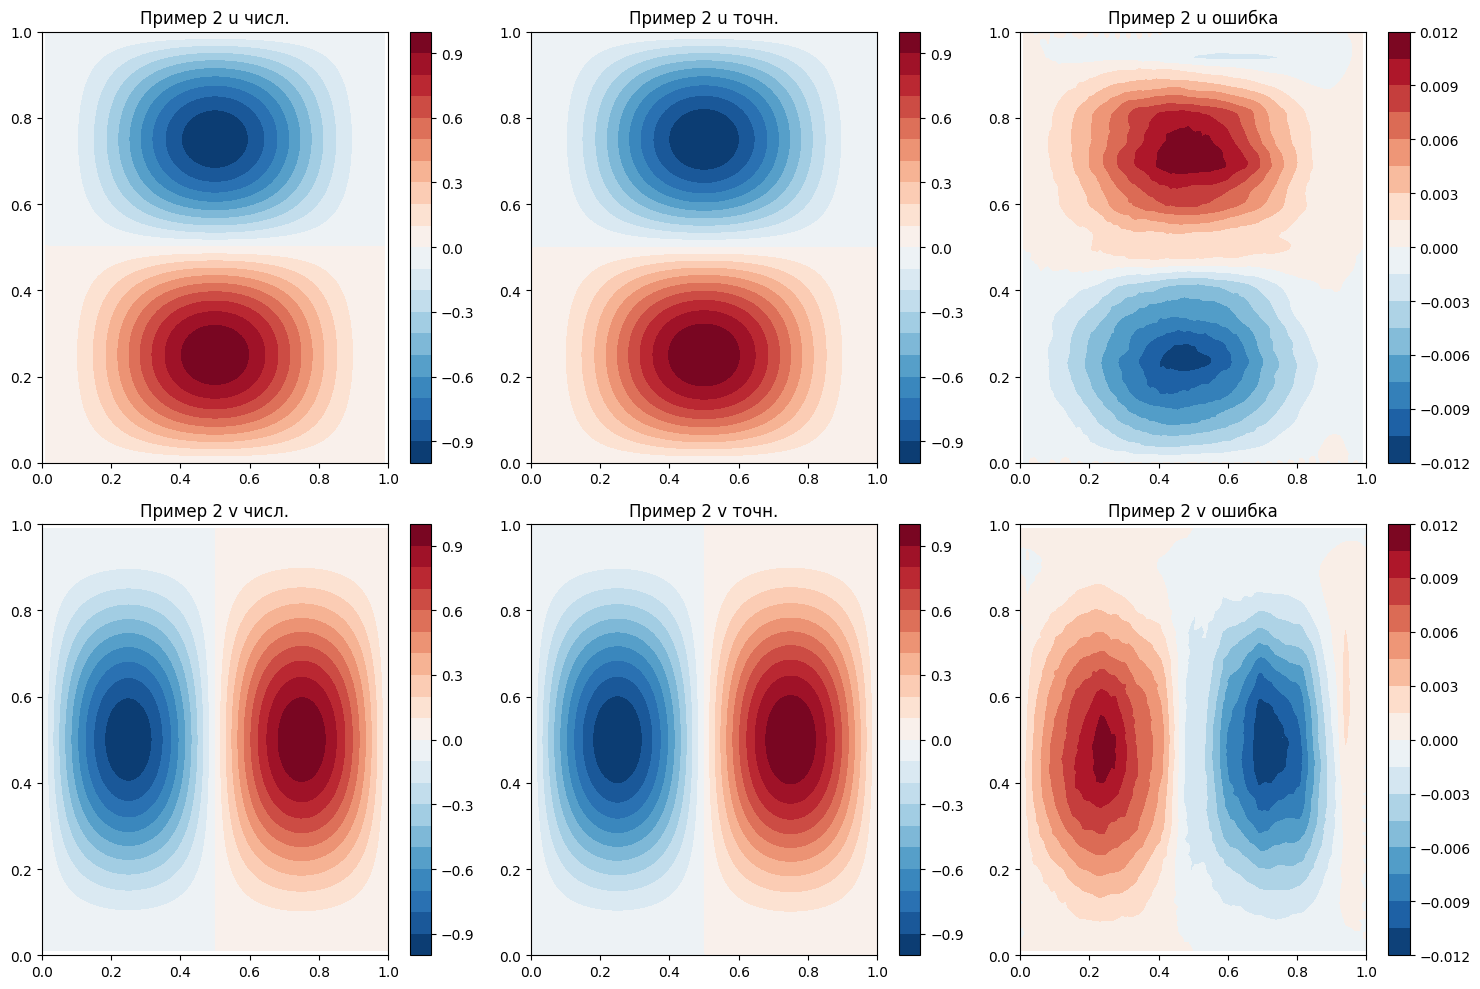

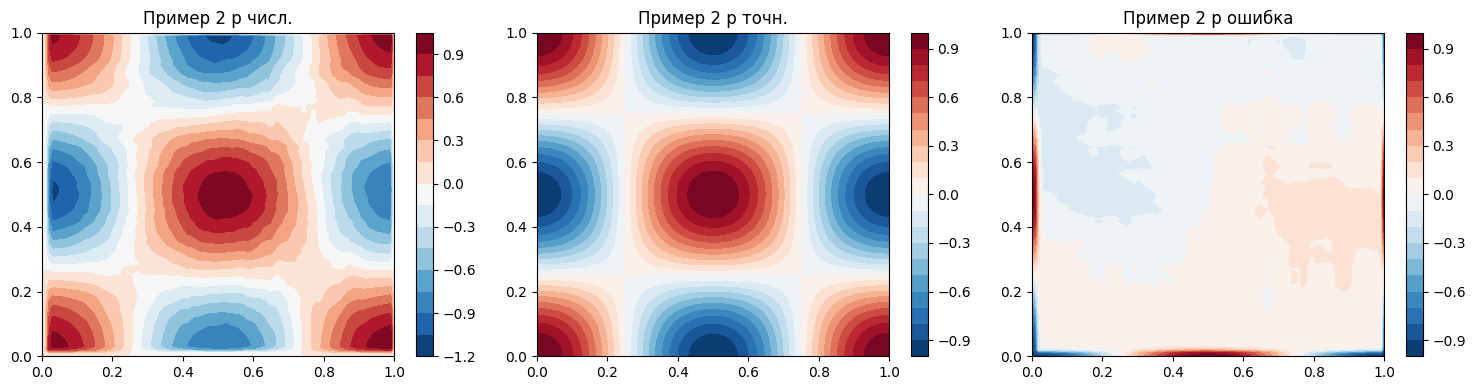

In [4]:
if __name__ == "__main__":
    for test in [2]:
        run_test(test, N=64, max_iter=5000, tol=1e-10, use_cg=True)
        #run_test(test, N=64, max_iter=5000, tol=1e-7, use_cg=True)


Тест 1, сетка 64x64, h=0.0156
DEBUG: N=64, n_u=4160, n_v=4160, n_p=4096
Построение матриц...
 Au: (4160, 4160), nnz=19784
 Av: (4160, 4160), nnz=19784
 B1: (4160, 4096), nnz=7812
 B2: (4160, 4096), nnz=7812
Построение правой части...
Решение методом Удзавы... (tau = 0.35)
iter=    0  ||r||=2.51e-02  tau=3.50e-01
Сходимость за 196 итераций, ||r||=9.22e-11
Время: 3.94 сек

Ошибки в L2-норме:
 ||u - u_h|| = 5.764039e-04
 ||v - v_h|| = 5.851602e-04
 ||p - p_h|| = 2.528322e-02


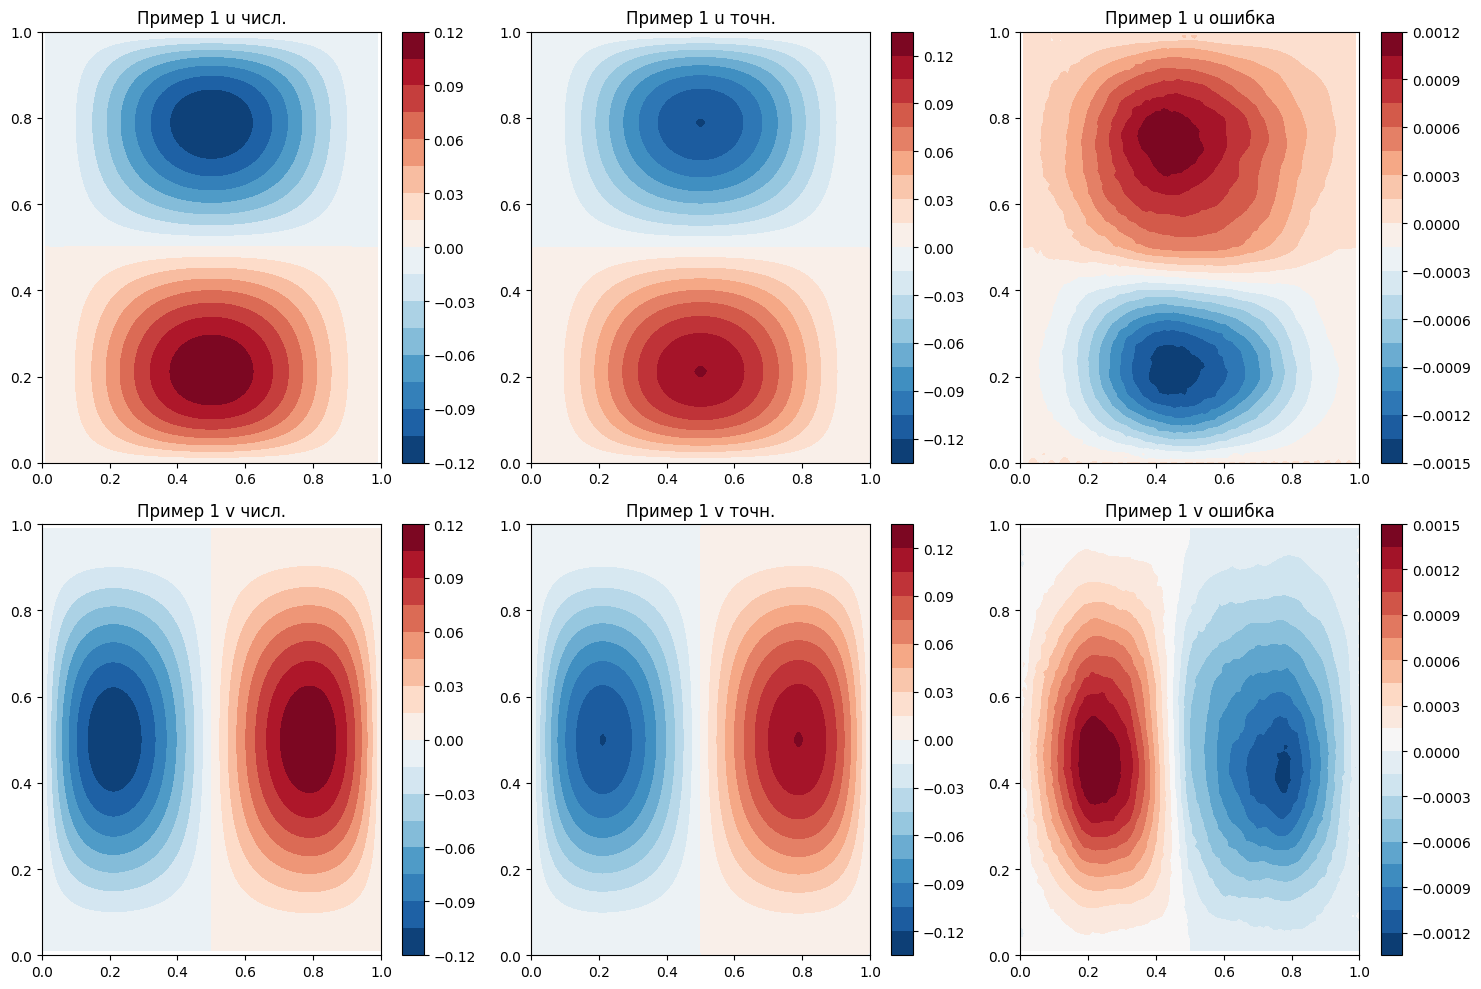

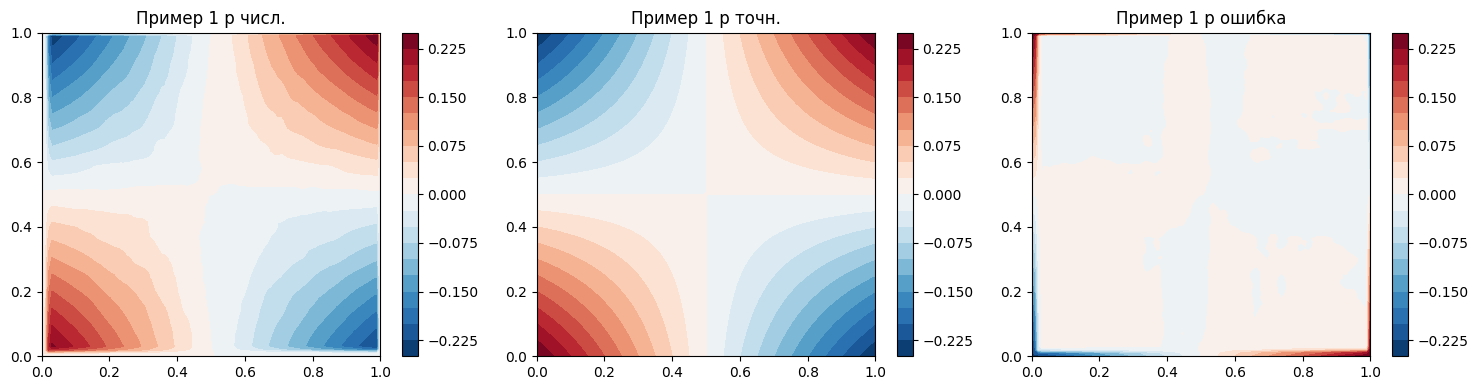

In [10]:
def run_test(test_num, N=32, max_iter=5000, tol=1e-7, use_cg=True, verbose=True):
    print(f"\n{'='*60}")
    print(f"Тест {test_num}, сетка {N}x{N}, h={1/N:.4f}")
    print(f"{'='*60}")
   
    if test_num == 1:
        u_exact, v_exact, p_exact = exact_u_test1, exact_v_test1, exact_p_test1
        f1_fun, f2_fun = rhs_f1_test1, rhs_f2_test1
        title = "Пример 1"
        tau_use = 0.35                     # ← ОПТИМАЛЬНО ДЛЯ ТЕСТА 1
    elif test_num == 2:
        u_exact, v_exact, p_exact = exact_u_test2, exact_v_test2, exact_p_test2
        f1_fun, f2_fun = rhs_f1_test2, rhs_f2_test2
        title = "Пример 2"
        tau_use = 0.55                     # ← ОПТИМАЛЬНО ДЛЯ ТЕСТА 2
    elif test_num == 3:
        u_exact, v_exact, p_exact = exact_u_test3, exact_v_test3, exact_p_test3
        f1_fun, f2_fun = rhs_f1_test3, rhs_f2_test3
        title = "Пример 3"
        tau_use = 0.80
    else:
        raise ValueError("test_num должен быть 1, 2 или 3")
   
    grid = MACGrid(N)
   
    print("Построение матриц...")
    Au, Av, B1, B2 = build_matrices(grid)
    print(f" Au: {Au.shape}, nnz={Au.nnz}")
    print(f" Av: {Av.shape}, nnz={Av.nnz}")
    print(f" B1: {B1.shape}, nnz={B1.nnz}")
    print(f" B2: {B2.shape}, nnz={B2.nnz}")
   
    print("Построение правой части...")
    f1_vec, f2_vec = build_rhs(grid, f1_fun, f2_fun)
   
    print(f"Решение методом Удзавы... (tau = {tau_use})")
    solver = UzawaSolver(grid, Au, Av, B1, B2, tau=tau_use, use_cg=use_cg)
    
    u, v, p, history = solver.solve(f1_vec, f2_vec, max_iter=max_iter, tol=tol, verbose=verbose)
   
    err_u, err_v, err_p = compute_errors(grid, u, v, p, u_exact, v_exact, p_exact)
   
    print(f"\nОшибки в L2-норме:")
    print(f" ||u - u_h|| = {err_u:.6e}")
    print(f" ||v - v_h|| = {err_v:.6e}")
    print(f" ||p - p_h|| = {err_p:.6e}")
   
    plot_solution(grid, u, v, p, u_exact, v_exact, p_exact, title)
    plt.savefig(f'test{test_num}_uzawa_uv_N{N}.png', dpi=150, bbox_inches='tight')
   
    plot_pressure(grid, p, p_exact, title)
    plt.savefig(f'test{test_num}_uzawa_p_N{N}.png', dpi=150, bbox_inches='tight')
   
    #plot_convergence(history)
    #plt.savefig(f'test{test_num}_uzawa_convergence_N{N}.png', dpi=150, bbox_inches='tight')
   
    plt.show()
   
    return err_u, err_v, err_p, history

if __name__ == "__main__":
    run_test(1, N=64, max_iter=2000, tol=1e-10, verbose=True)   # ← сначала только тест 1


Тест 1, сетка 32x32, h=0.0312
DEBUG: N=32, n_u=1056, n_v=1056, n_p=1024
Построение матриц...
 Au: (1056, 1056), nnz=4776
 Av: (1056, 1056), nnz=4776
 B1: (1056, 1024), nnz=1860
 B2: (1056, 1024), nnz=1860
Построение правой части...
Решение методом Удзавы...
iter=    0  ||r||=1.46e-01  tau=5.00e-01
Сходимость за 123 итераций, ||r||=9.24e-11
Время: 1.72 сек

Ошибки в L2-норме:
 ||u - u_h|| = 4.264138e-02
 ||v - v_h|| = 4.264138e-02
 ||p - p_h|| = 2.598439e-01


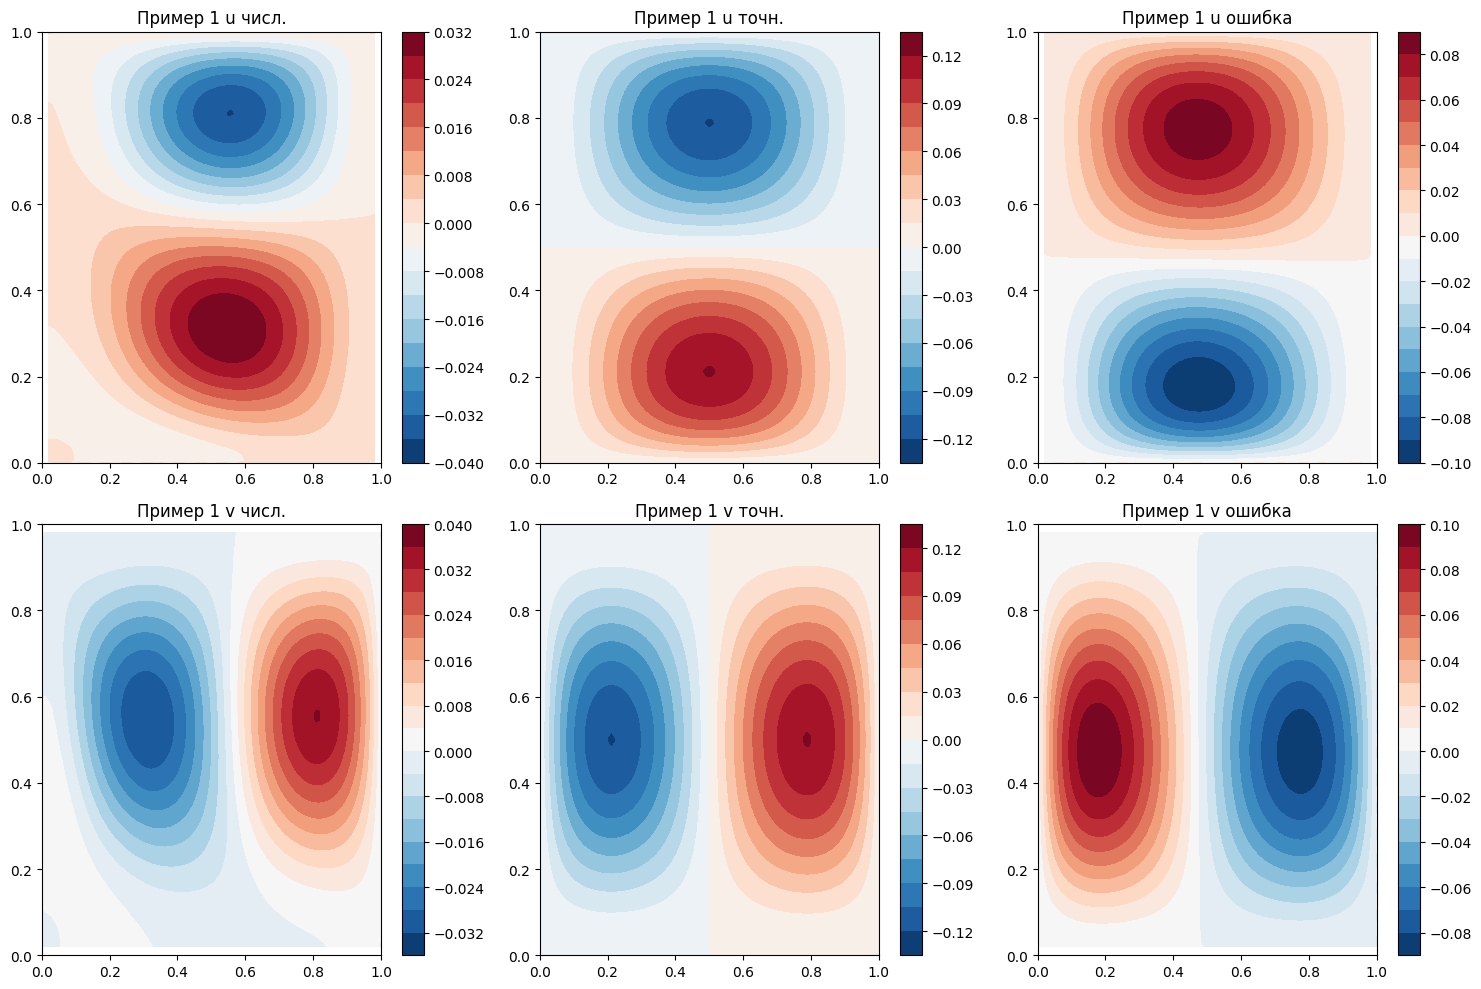

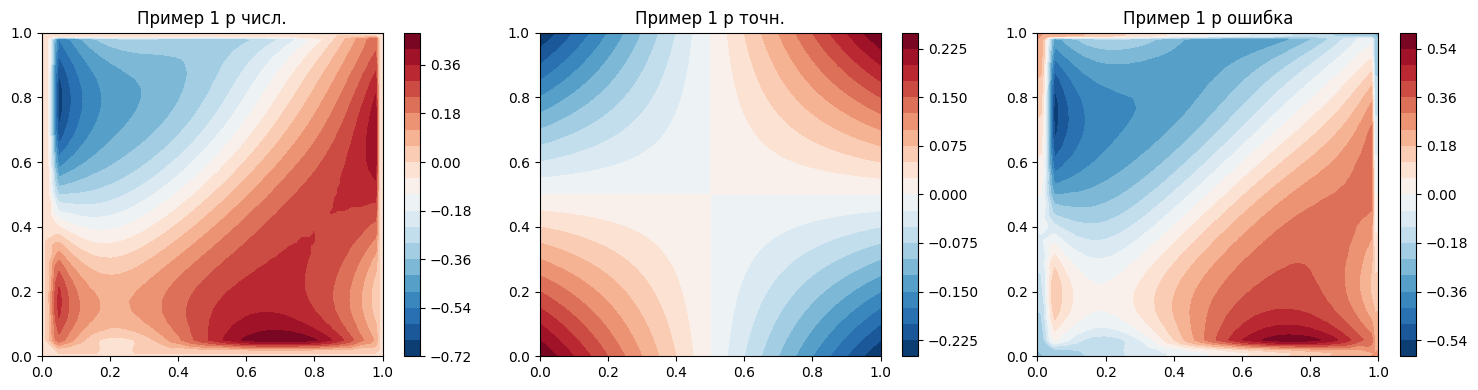

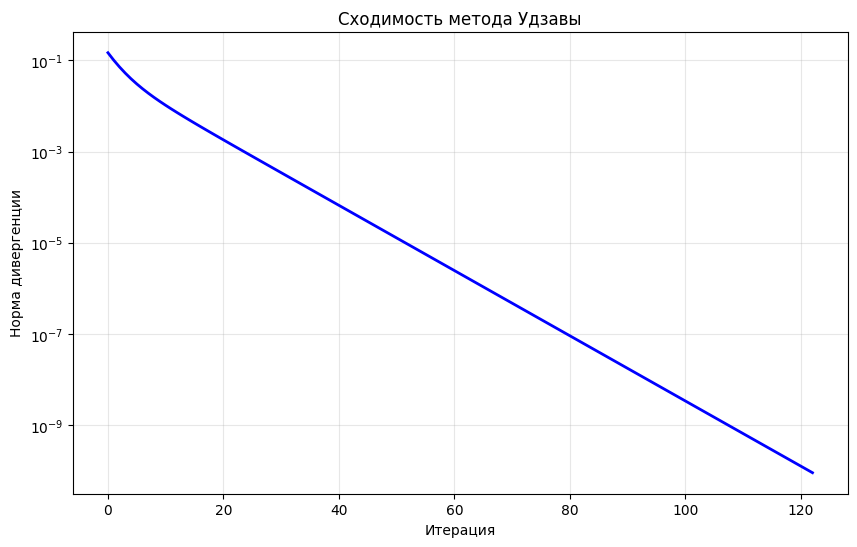

In [49]:
if __name__ == "__main__":
    for test in [1]:
        run_test(test, N=32, max_iter=15000, tol=1e-10, use_cg=True, tau=0.5)

In [11]:
if __name__ == "__main__":
    # Быстрый тест (рекомендую)
    run_test(1, N=32, max_iter=800, tol=1e-8, tau=0.8)
    
    # Или все тесты
    for test in [1, 2, 3]:
        run_test(test, N=64, max_iter=1200, tol=1e-8, tau=0.8)

TypeError: run_test() got an unexpected keyword argument 'tau'

In [28]:
def run_continuation_experiment(N=64, tau=0.8):
    """Продолжение по параметру λ для Примера 3 + графики u и v"""
    print("\n=== Продолжение по параметру (Пример 3, N=64) ===")
    print("λ от -1 до 1. Для каждого λ строим графики u и v.\n")
    
    grid = MACGrid(N)
    Au, Av, B1, B2 = build_matrices(grid)
    
    lambdas = [-10.0, -1.0, -0.5, 0.5, 1.0, 5.0, 7.0, 8.0, 9.0, 9.5, 9.7, 10.0]
    
    print("λ      ||u||_err      ||v||_err      ||p||_err      Итераций")
    print("-" * 70)
    
    for lam in lambdas:
        # Масштабируем правую часть
        def f1_lam(x, y): return lam * rhs_f1_test3(x, y)
        def f2_lam(x, y): return lam * rhs_f2_test3(x, y)
        
        f1_vec, f2_vec = build_rhs(grid, f1_lam, f2_lam)
        
        # Решаем
        solver = UzawaSolver(grid, Au, Av, B1, B2, tau=tau, use_cg=True)
        u, v, p, history = solver.solve(f1_vec, f2_vec, 
                                        max_iter=1500, tol=1e-8, verbose=False)
        
        # Масштабируем точное решение
        def u_ex_lam(x, y): return lam * exact_u_test3(x, y)
        def v_ex_lam(x, y): return lam * exact_v_test3(x, y)
        def p_ex_lam(x, y): return lam * exact_p_test3(x, y)
        
        err_u, err_v, err_p = compute_errors(grid, u, v, p, 
                                             u_ex_lam, v_ex_lam, p_ex_lam)
        
        iters = len(history)
        print(f"{lam:5.1f}   {err_u:.2e}    {err_v:.2e}    {err_p:.2e}     {iters:4d}")
        
        # === РИСУЕМ ГРАФИКИ u и v ===
        title = f"Пример 3, λ = {lam}"
        fig = plot_solution(grid, u, v, p,          # p не используется в графиках u/v
                            u_ex_lam, v_ex_lam, p_ex_lam, title=title)
        
        # Сохраняем только u/v графики (3-й столбец с p можно игнорировать)
        filename = f"continuation_lambda_{lam:.1f}_uv_N{N}.png"
        fig.savefig(filename, dpi=180, bbox_inches='tight')
        plt.close(fig)   # закрываем, чтобы не засорять память
        
        print(f"   → Графики сохранены: {filename}")
    
    print("\nЭксперимент завершён. Все графики u и v для λ = -1, -0.5, 0.5, 1 сохранены.")

run_continuation_experiment()


=== Продолжение по параметру (Пример 3, N=64) ===
λ от -1 до 1. Для каждого λ строим графики u и v.

DEBUG: N=64, n_u=4160, n_v=4160, n_p=4096
λ      ||u||_err      ||v||_err      ||p||_err      Итераций
----------------------------------------------------------------------
Время: 0.90 сек
 -1.0   7.09e-04    7.09e-04    1.29e-01       57
   → Графики сохранены: continuation_lambda_-1.0_uv_N64.png
Время: 0.85 сек
 -0.5   3.54e-04    3.54e-04    6.43e-02       55
   → Графики сохранены: continuation_lambda_-0.5_uv_N64.png
Время: 0.87 сек
  0.5   3.54e-04    3.54e-04    6.43e-02       55
   → Графики сохранены: continuation_lambda_0.5_uv_N64.png
Время: 0.88 сек
  1.0   7.09e-04    7.09e-04    1.29e-01       57
   → Графики сохранены: continuation_lambda_1.0_uv_N64.png

Эксперимент завершён. Все графики u и v для λ = -1, -0.5, 0.5, 1 сохранены.


In [13]:
def run_continuation_experiment(N=64, tau=0.8):
    """Продолжение по параметру λ для Примера 3 + графики u, v и p"""
    print("\n=== Продолжение по параметру (Пример 3, N=64) ===")
    print("λ от -10 до 10. Для каждого λ строим графики u, v и p.\n")
   
    grid = MACGrid(N)
    Au, Av, B1, B2 = build_matrices(grid)
   
    lambdas = [-10.0, -1.0, -0.5, 0.5, 1.0, 5.0, 7.0, 8.0, 9.0, 9.5, 9.7, 10.0]
   
    print("λ      ||u||_err      ||v||_err      ||p||_err      Итераций")
    print("-" * 75)
   
    for lam in lambdas:
        # Масштабируем правую часть
        def f1_lam(x, y): return lam * rhs_f1_test3(x, y)
        def f2_lam(x, y): return lam * rhs_f2_test3(x, y)
        #def f1_lam(x, y): return lam * 10
        #def f2_lam(x, y): return lam * 10
        f1_vec, f2_vec = build_rhs(grid, f1_lam, f2_lam)
       
        # Решаем
        solver = UzawaSolver(grid, Au, Av, B1, B2, tau=tau, use_cg=True)
        u, v, p, history = solver.solve(f1_vec, f2_vec,
                                        max_iter=2000, tol=1e-8, verbose=False)
       
        # Масштабируем точное решение
        def u_ex_lam(x, y): return lam * exact_u_test3(x, y)
        def v_ex_lam(x, y): return lam * exact_v_test3(x, y)
        def p_ex_lam(x, y): return lam * exact_p_test3(x, y)
        
        err_u, err_v, err_p = compute_errors(grid, u, v, p,
                                             u_ex_lam, v_ex_lam, p_ex_lam)
       
        iters = len(history)
        print(f"{lam:6.1f}   {err_u:.2e}    {err_v:.2e}    {err_p:.2e}     {iters:4d}")
       
        # === ГРАФИКИ u и v ===
        title = f"Пример 3, λ = {lam}"
        fig_uv = plot_solution(grid, u, v, p,
                               u_ex_lam, v_ex_lam, p_ex_lam, title=title)
        
        filename_uv = f"continuation_lambda_{lam:.1f}_uv_N{N}.png"
        fig_uv.savefig(filename_uv, dpi=180, bbox_inches='tight')
        plt.close(fig_uv)
        print(f"   → u/v графики: {filename_uv}")
       
        # === ГРАФИКИ ДАВЛЕНИЯ p ===
        fig_p = plot_pressure(grid, p, p_ex_lam, title=title)
        
        filename_p = f"continuation_lambda_{lam:.1f}_p_N{N}.png"
        fig_p.savefig(filename_p, dpi=180, bbox_inches='tight')
        plt.close(fig_p)
        print(f"   → p графики:   {filename_p}")
   
    print("\nЭксперимент завершён.")
    print("Сохранены графики u, v и p для всех λ.")

run_continuation_experiment(N=64, tau=0.8)


=== Продолжение по параметру (Пример 3, N=64) ===
λ от -10 до 10. Для каждого λ строим графики u, v и p.

DEBUG: N=64, n_u=4160, n_v=4160, n_p=4096
λ      ||u||_err      ||v||_err      ||p||_err      Итераций
---------------------------------------------------------------------------
Время: 1.52 сек
 -10.0   2.17e+00    2.17e+00    3.99e+01       85
   → u/v графики: continuation_lambda_-10.0_uv_N64.png
   → p графики:   continuation_lambda_-10.0_p_N64.png
Время: 1.35 сек
  -1.0   2.17e-01    2.17e-01    3.99e+00       76
   → u/v графики: continuation_lambda_-1.0_uv_N64.png
   → p графики:   continuation_lambda_-1.0_p_N64.png
Время: 1.31 сек
  -0.5   1.08e-01    1.08e-01    1.99e+00       73
   → u/v графики: continuation_lambda_-0.5_uv_N64.png
   → p графики:   continuation_lambda_-0.5_p_N64.png
Время: 1.32 сек
   0.5   1.08e-01    1.08e-01    1.99e+00       73
   → u/v графики: continuation_lambda_0.5_uv_N64.png
   → p графики:   continuation_lambda_0.5_p_N64.png
Время: 1.37 сек
  

In [3]:
def run_continuation_experiment(N=64, tau=0.8):
    """Продолжение по параметру λ для Примера 3 + графики u, v и p"""
    print("\n=== Продолжение по параметру (Пример 3, N=64) ===")
    print("λ от -10 до 10. Для каждого λ строим графики u, v и p.\n")
   
    grid = MACGrid(N)
    Au, Av, B1, B2 = build_matrices(grid)
   
    lambdas = [1.0]
   
    print("λ      ||u||_err      ||v||_err      ||p||_err      Итераций")
    print("-" * 75)
   
    for lam in lambdas:
        # Масштабируем правую часть
        def f1_lam(x, y): return 10 * lam * np.sin(5*np.pi*x)*np.sin(np.pi * y) * np.exp(-5*x)
        def f2_lam(x, y): return lam * 0
        f1_vec, f2_vec = build_rhs(grid, f1_lam, f2_lam)
       
        # Решаем
        solver = UzawaSolver(grid, Au, Av, B1, B2, tau=tau, use_cg=True)
        u, v, p, history = solver.solve(f1_vec, f2_vec,
                                        max_iter=2000, tol=1e-8, verbose=False)
        # Масштабируем точное решение
        def u_ex_lam(x, y): return lam * exact_u_test3(x, y)
        def v_ex_lam(x, y): return lam * exact_v_test3(x, y)
        def p_ex_lam(x, y): return lam * exact_p_test3(x, y)
        
        err_u, err_v, err_p = compute_errors(grid, u, v, p,
                                             u_ex_lam, v_ex_lam, p_ex_lam)
       
        iters = len(history)
        print(f"{lam:6.1f}   {err_u:.2e}    {err_v:.2e}    {err_p:.2e}     {iters:4d}")
       
        # === ГРАФИКИ u и v ===
        title = f"Пример 3, λ = {lam}"
        fig_uv = plot_solution(grid, u, v, p,
                               u_ex_lam, v_ex_lam, p_ex_lam, title=title)
        
        filename_uv = f"continuation_lambda_{lam:.1f}_uv_N{N}.png"
        fig_uv.savefig(filename_uv, dpi=180, bbox_inches='tight')
        plt.close(fig_uv)
        print(f"   → u/v графики: {filename_uv}")
       
        # === ГРАФИКИ ДАВЛЕНИЯ p ===
        fig_p = plot_pressure(grid, p, p_ex_lam, title=title)
        
        filename_p = f"continuation_lambda_{lam:.1f}_p_N{N}.png"
        fig_p.savefig(filename_p, dpi=180, bbox_inches='tight')
        plt.close(fig_p)
        print(f"   → p графики:   {filename_p}")
   
    print("\nЭксперимент завершён.")
    print("Сохранены графики u, v и p для всех λ.")

run_continuation_experiment(N=64, tau=0.8)      


=== Продолжение по параметру (Пример 3, N=64) ===
λ от -10 до 10. Для каждого λ строим графики u, v и p.

DEBUG: N=64, n_u=4160, n_v=4160, n_p=4096
λ      ||u||_err      ||v||_err      ||p||_err      Итераций
---------------------------------------------------------------------------
Время: 0.88 сек
   1.0   2.17e-01    2.17e-01    5.01e-01       51
   → u/v графики: continuation_lambda_1.0_uv_N64.png
   → p графики:   continuation_lambda_1.0_p_N64.png

Эксперимент завершён.
Сохранены графики u, v и p для всех λ.
